# Baseline Model Implementation


In [9]:
#Import Libs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch 
import torch.nn as nn 
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [10]:
#Reading Datasets
dataset_a = pd.read_csv('../data/spilts/dataset_a.csv')
dataset_b = pd.read_csv('../data/spilts/dataset_b.csv')

print(f'Dataset A dim:{dataset_a.shape}')
print(f'Dataset B dim:{dataset_b.shape}')

Dataset A dim:(2697, 9)
Dataset B dim:(2533, 9)


In [11]:
dataset_a

,compound_encoded,TyreLife,tyre_life_norm,LapNumber,lapnumber_norm,StintNumber,LapTimeSeconds,Race,Driver
0,0,5.0,0.000000,2.0,0.035088,1,96.296,Bahrain,VER
1,0,6.0,0.071429,3.0,0.052632,1,96.753,Bahrain,VER
2,0,7.0,0.142857,4.0,0.070175,1,96.647,Bahrain,VER
3,0,8.0,0.214286,5.0,0.087719,1,97.173,Bahrain,VER
4,0,9.0,0.285714,6.0,0.105263,1,97.092,Bahrain,VER
...,...,...,...,...,...,...,...,...,...
2692,2,14.0,0.733333,52.0,0.912281,3,80.295,Australia,PIA
2693,2,15.0,0.799999,53.0,0.929825,3,80.308,Australia,PIA
2694,2,16.0,0.866666,54.0,0.947368,3,80.199,Australia,PIA
2695,2,17.0,0.933333,55.0,0.964912,3,80.754,Australia,PIA


In [12]:
#Define Features 
Features = ['compound_encoded','TyreLife','tyre_life_norm','LapNumber','lapnumber_norm','StintNumber']
Target = 'LapTimeSeconds'

X_a = dataset_a[Features].values
Y_a = dataset_a[Target].values

X_b = dataset_b[Features].values
Y_b = dataset_b[Target].values


print(f'X_a dim:{X_a.shape}')
print(f'Y_a dim:{Y_a.shape}')
print(f'X_b dim:{X_b.shape}')
print(f'Y_a dim:{Y_b.shape}')

X_a dim:(2697, 6)
Y_a dim:(2697,)
X_b dim:(2533, 6)
Y_a dim:(2533,)


In [21]:
# Scaling Parameters for Neural Netweork Traning
Scaler = StandardScaler()
X_a_scaled = Scaler.fit_transform(X_a)
X_b_scaled = Scaler.transform(X_b)

In [25]:
# Converting into Pytorch Tensors
X_a_tensor = torch.FloatTensor(X_a_scaled)
Y_a_tensor = torch.FloatTensor(Y_a).reshape(-1,1)

X_b_tensor = torch.FloatTensor(X_b_scaled)
Y_b_tensor = torch.FloatTensor(Y_b).reshape(-1,1)

#Matching Index and Label usinf TensorDataSet
dataset_a_torch = TensorDataset(X_a_tensor,Y_a_tensor)
dataset_b_torch = TensorDataset(X_b_tensor,Y_b_tensor)

# Data Loading 
loader_a = DataLoader(dataset_a_torch, batch_size = 64, shuffle = True)
loader_b = DataLoader(dataset_b_torch, batch_size = 64, shuffle = True)

#Printing 
print(f'Data Loader A batches:{len(loader_a)}')
print(f'Data Loader B batches:{len(loader_b)}')

Data Loader A batches:43
Data Loader B batches:40


In [26]:
#Define Neural Network
class LapTimeNet(nn.Module):
    def __init__(self,input_size):
        super(LapTimeNet,self).__init__()
        self.network = nn.Sequential(
        nn.Linear(input_size,64),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(64,32),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(32,1)
    )

    def forward(self,x):
        return self.network(x)

model = LapTimeNet(input_size=len(Features))
print(model)
print(f'Total parameters:{sum(p.numel() for p in model.parameters())}')
        

LapTimeNet(
  (network): Sequential(
    (0): Linear(in_features=6, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)
Total parameters:2561


In [30]:
#CUDA 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
print(f'GPU Name: {torch.cuda.get_device_name(0)}')
print(f'Memory Allocated: {torch.cuda.memory_allocated(0)/1024**2:.2f} MB')

Using device: cuda
GPU Name: NVIDIA GeForce RTX 5060 Laptop GPU
Memory Allocated: 0.00 MB


In [48]:
#Training Function
def train_model(model,loader,epoch=50,lr=0.001):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(),lr)

    loss_history = []

    for epoch in range(epoch):
        model.train()
        epoch_loss = 0

        for X_batch, Y_batch in loader:
            optimizer.zero_grad()
            prediction = model(X_batch)
            loss = criterion(prediction,Y_batch)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss/len(loader)
        loss_history.append(avg_loss)

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epoch} — Loss: {avg_loss:.4f}")

    return loss_history

In [55]:
#Eval Function 
def eval_model(model,X_tensor,y_true):
    model.eval()

    with torch.no_grad():
        prediction = model(X_tensor).numpy().flatten()

    mae = mean_absolute_error(y_true,prediction)
    rmse = np.sqrt(mean_squared_error(y_true, prediction))


    return mae,rmse,prediction

In [56]:
#Training Datasets
print("Training on Dataset A...")
loss_history_a = train_model(model, loader_a, epoch=50)

# evaluate on Dataset A
mae_a, rmse_a, preds_a = eval_model(model, X_a_tensor, Y_a)
print(f"\nDataset A — MAE: {mae_a:.3f}s | RMSE: {rmse_a:.3f}s")

# save model checkpoint
torch.save(model.state_dict(), '../outputs/models/model_after_A.pt')
print("Model saved")

Training on Dataset A...
Epoch 10/9 — Loss: 164.3232
Epoch 20/19 — Loss: 162.5496
Epoch 30/29 — Loss: 163.7926
Epoch 40/39 — Loss: 158.4490
Epoch 50/49 — Loss: 158.3622

Dataset A — MAE: 5.176s | RMSE: 5.837s
Model saved


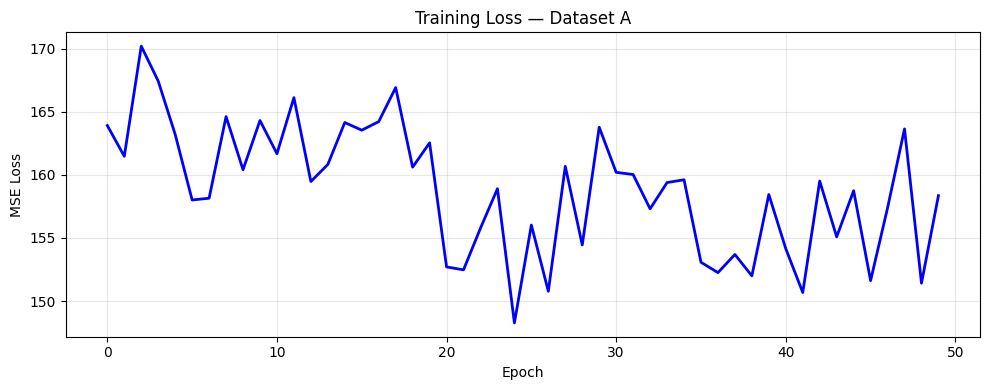

In [57]:
plt.figure(figsize=(10, 4))
plt.plot(loss_history_a, color='blue', linewidth=2)
plt.title('Training Loss — Dataset A')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/plots/training_loss_a.png')
plt.show()

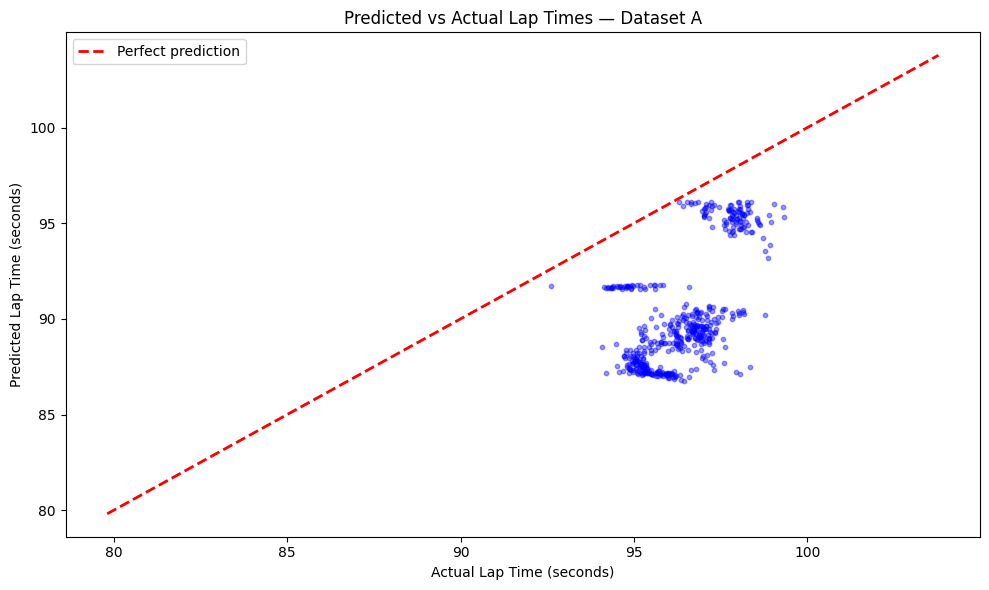

In [59]:
plt.figure(figsize=(10, 6))
plt.scatter(Y_a[:500], preds_a[:500], alpha=0.4, color='blue', s=10)
plt.plot([Y_a.min(), Y_a.max()], [Y_a.min(), Y_a.max()], 
         'r--', linewidth=2, label='Perfect prediction')
plt.title('Predicted vs Actual Lap Times — Dataset A')
plt.xlabel('Actual Lap Time (seconds)')
plt.ylabel('Predicted Lap Time (seconds)')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/plots/pred_vs_actual_a.png')
plt.show()

In [62]:
mae_b_before, rmse_b_before, _ = eval_model(model, X_b_tensor, Y_b)
print(f"Dataset B (before fine-tuning) — MAE: {mae_b_before:.3f}s | RMSE: {rmse_b_before:.3f}s")

Dataset B (before fine-tuning) — MAE: 5.958s | RMSE: 7.000s
